In [180]:
df = pd.read_csv('train.csv')
df

,store_id,store_name,date,revenue
0,0,All Stores,2011-01-29,204126.52
1,0,All Stores,2011-01-30,197426.42
2,0,All Stores,2011-01-31,144267.27
3,0,All Stores,2011-02-01,151903.00
4,0,All Stores,2011-02-02,117399.88
...,...,...,...,...
18761,10,Wisconsin – Badger Crossing,2015-09-26,25689.55
18762,10,Wisconsin – Badger Crossing,2015-09-27,26557.53
18763,10,Wisconsin – Badger Crossing,2015-09-28,19067.53
18764,10,Wisconsin – Badger Crossing,2015-09-29,16467.95


# Data Prep

In [181]:
import pandas as pd
df = pd.read_csv('train.csv')
calender_events =  pd.read_csv('calendar_events.csv')
df = df.merge( calender_events, on='date', how = 'left')
df

,store_id,store_name,date,revenue,event
0,0,All Stores,2011-01-29,204126.52,NaN
1,0,All Stores,2011-01-30,197426.42,NaN
2,0,All Stores,2011-01-31,144267.27,NaN
3,0,All Stores,2011-02-01,151903.00,NaN
4,0,All Stores,2011-02-02,117399.88,NaN
...,...,...,...,...,...
18761,10,Wisconsin – Badger Crossing,2015-09-26,25689.55,NaN
18762,10,Wisconsin – Badger Crossing,2015-09-27,26557.53,NaN
18763,10,Wisconsin – Badger Crossing,2015-09-28,19067.53,NaN
18764,10,Wisconsin – Badger Crossing,2015-09-29,16467.95,NaN


In [ ]:
#make events a binary yes or no
df['event_binary'] = df['event'].notna().astype(int)
#make features lagged
df = df.sort_values(['store_id', 'date'])

for lag in [1, 2, 7, 14, 30, 90, 60, 364]:
    df[f'lag_{lag}'] = df.groupby('store_id')['revenue'].shift(lag)
    window = lag
    df[f'rolling_std_{window}']  = df.groupby('store_id')['revenue'].transform(
        lambda x: x.shift(1).rolling(window).std())


df['momentum_7']  = df['lag_7']  - df['lag_14']   # need lag_14
df['momentum_30'] = df['lag_30'] - df['lag_60'] 

#features day of week and month 
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month


FEATURES = ['event_binary', 'lag_1', 'lag_2', 'day_of_week', 'month','lag_7' ,'lag_30', 'lag_90' , 'momentum_7', 'momentum_30',  'rolling_std_7', 'rolling_std_30','lag_364']


# #tomorrws revenue
# df['target_daily'] = df.groupby('store_id')['revenue'].shift(-1)
# #todays revenue 
# df['target_monthly'] = df.groupby('store_id')['revenue'].shift(-30)
# df
# 


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
def train_test_split_90(store_df):
    store_df = store_df.sort_values('date').reset_index(drop=True)
    test  = store_df.tail(90)        # last 90 rows regardless of calendar gaps
    train = store_df.iloc[:-90]
    split_date = train['date'].max()
    return train, test, split_date

# ── 3. HORIZON-SHIFTED TRAINING DATA ────────────────────────────────────────

def make_horizon_df(store_df, horizon):
    """
    Target becomes revenue `horizon` days into the future.
    Features are the same lagged features from the current row.
    """
    d = store_df.copy()
    d['target'] = d['revenue'].shift(-horizon)
    return d.dropna(subset=FEATURES + ['target'])

# ── 4. RECURSIVE PREDICTION HELPERS ─────────────────────────────────────────
def make_future_row(pred_date, last_known, event_calendar):
    def get_lag(n):
        return last_known.get(pred_date - pd.Timedelta(days=n), np.nan)

    recent_vals = [last_known.get(pred_date - pd.Timedelta(days=k), np.nan) for k in range(1, 8)]

    return {
        'date':             pred_date,
        'event_binary':     event_calendar.get(pred_date, 0),
        'days_since_event': 0,  # simplified for future dates
        'lag_1':            get_lag(1),
        'lag_2':            get_lag(2),
        'lag_7':            get_lag(7),
        # 'lag_14':           get_lag(14),
        'lag_30':           get_lag(30),
        # 'lag_60':           get_lag(60),
        'lag_90':           get_lag(90),
        'lag_364':          get_lag(364),
        # 'rolling_mean_7':   np.nanmean(recent_vals),
        # 'rolling_mean_14':  np.nanmean([last_known.get(pred_date - pd.Timedelta(days=k), np.nan) for k in range(1, 15)]),
        # 'rolling_mean_30':  np.nanmean([last_known.get(pred_date - pd.Timedelta(days=k), np.nan) for k in range(1, 31)]),
        'rolling_std_7':    np.nanstd(recent_vals),
        'rolling_std_30':   np.nanstd([last_known.get(pred_date - pd.Timedelta(days=k), np.nan) for k in range(1, 31)]),
        'momentum_7':       get_lag(7)  - get_lag(14),
        'momentum_30':      get_lag(30) - get_lag(60),
        'day_of_week':      pred_date.dayofweek,
        'is_weekend':       int(pred_date.dayofweek >= 5),
        'month':            pred_date.month,
        'week_of_year':     pred_date.isocalendar()[1],
    }

def recursive_predict(model, horizon_days, last_known, start_date, event_calendar):
    preds   = []
    running = dict(last_known)

    for i in range(horizon_days):
        pred_date = start_date + pd.Timedelta(days=i)
        row       = make_future_row(pred_date, running, event_calendar)
        X         = pd.DataFrame([row])[FEATURES]
        y_hat     = model.predict(X)[0]
        running[pred_date] = y_hat
        preds.append((pred_date, y_hat))

    return preds


def recursive_predict_chunked(model, total_days, chunk_size, last_known,
                               start_date, event_calendar):
    """
    Predict in blocks of chunk_size days.
    Each completed chunk is written back to running before the next chunk starts.
    Daily  (chunk=1)  → predicts 1 day, feeds back, repeats
    Monthly(chunk=30) → predicts 30 days, feeds back whole block, repeats
    Quarterly(chunk=90)→ predicts all 90 days in one shot
    """
    all_preds     = []
    running       = dict(last_known)
    current_start = start_date
    days_left     = total_days

    while days_left > 0:
        chunk       = min(chunk_size, days_left)
        chunk_preds = recursive_predict(model, chunk, running,
                                        current_start, event_calendar)
        for date, val in chunk_preds:
            running[date] = val
        all_preds.extend(chunk_preds)
        current_start += pd.Timedelta(days=chunk)
        days_left     -= chunk

    return all_preds

# ── 5. TRAIN 3 MODELS PER STORE & EVALUATE ──────────────────────────────────

# XGB_PARAMS = dict(
#     n_estimators    = 300,
#     learning_rate   = 0.05,
#     max_depth       = 6,
#     subsample       = 0.8,
#     colsample_bytree= 0.8,
#     random_state    = 42,
#     n_jobs          = -1,
# )
# XGB_PARAMS = dict(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=3,        # was 6 — shallower trees generalise better
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_alpha=1.0,      # L1 regularisation
#     reg_lambda=5.0,     # L2 regularisation
# )

import numpy as np

# ─────────────────────────────────────────────
# XGBoost Starter Parameters
# Tuned for: tabular regression, medium-large datasets
# Objective: tweedie (swap for your use case)
# ─────────────────────────────────────────────

XGB_PARAMS = dict(

    # ── Objective ────────────────────────────────────────────────────────────
    objective="reg:tweedie",        # tweedie for count/sales data with zeros
    tweedie_variance_power=1.1,     # 1.0=Poisson, 2.0=Gamma; 1.1 suits unit sales
    eval_metric="tweedie-nloglik@1.1",  # must match variance_power

    # ── Hardware ─────────────────────────────────────────────────────────────
    device="cuda",                  # "cuda" (GPU) or "cpu" — tree_method inferred
    tree_method="hist",             # hist = fast approximate; exact = small data only
    max_bin=256,                    # 64–128 saves RAM; 256 default is usually fine

    # ── Tree Structure ────────────────────────────────────────────────────────
    max_depth=6,                    # sweet spot: 4–8; go deeper for high-order interactions
    min_child_weight=20,            # higher → less splitting → less overfit on sparse data
    max_leaves=0,                   # 0 = unlimited (depth controls); set e.g. 64 for leaf-wise

    # ── Shrinkage & Sampling ─────────────────────────────────────────────────
    learning_rate=0.05,             # alias: eta. Pair with n_estimators via early stopping
    n_estimators=2000,              # set high; rely on early stopping to find the true optimum
    subsample=0.8,                  # row sampling per tree; 0.6–0.9 typical
    colsample_bytree=0.8,           # feature sampling per tree; 0.6–1.0 typical
    colsample_bylevel=1.0,          # additional sampling per depth level; usually leave at 1
    colsample_bynode=1.0,           # sampling per split node; useful for very wide data

    # ── Regularisation ───────────────────────────────────────────────────────
    reg_lambda=1.0,                 # L2 on leaf weights; default=1; increase to shrink leaves
    reg_alpha=0.0,                  # L1 on leaf weights; >0 induces sparsity in leaf weights
    gamma=0.0,                      # min loss reduction to make a split; 0 = no constraint

    # ── Reproducibility ──────────────────────────────────────────────────────
    seed=42,
    nthread=-1,                     # -1 = use all cores

)

store_models  = {}  # {store_name: {'daily': model, 'monthly': model, 'quarterly': model}}
store_results = {}  # {store_name: {'daily': df, 'monthly': df, 'quarterly': df}}

MODEL_CONFIGS = [
    ('daily',     1,  1),   # (name, training horizon, prediction chunk size)
    ('monthly',  30, 30),
    ('quarterly',90, 90),
]

for store_name, group in df.groupby('store_name'):
    group      = group.sort_values('date').reset_index(drop=True)
    train_df, test_df, split_date = train_test_split_90(group)

    last_known = dict(zip(train_df['date'], train_df['revenue']))
    event_cal  = dict(zip(group['date'],    group['event_binary']))
    test_start = test_df['date'].min()

    print(f"\n{'='*65}")
    print(f"Store : {store_name}")
    print(f"Train : up to {split_date.date()}  |  "
          f"Test  : {test_start.date()} → {test_df['date'].max().date()}  "
          f"({len(test_df)} rows)")

    models  = {}
    results = {}

    for model_name, train_horizon, chunk_size in MODEL_CONFIGS:

        # Each model trained to predict a different horizon ahead
        train_h = make_horizon_df(train_df, train_horizon)
        X_train = train_h[FEATURES]
        y_train = train_h['target']

        model = XGBRegressor(**XGB_PARAMS)
        model.fit(X_train, y_train, verbose=False)

        # All 3 models predict the same 90-day test window
        preds = recursive_predict_chunked(
            model          = model,
            total_days     = 90,
            chunk_size     = chunk_size,
            last_known     = last_known,
            start_date     = test_start,
            event_calendar = event_cal,
        )

        pred_df = pd.DataFrame(preds, columns=['date', 'pred_revenue'])
        merged  = test_df[['date', 'revenue']].merge(pred_df, on='date', how='inner')

        mae  = mean_absolute_error(merged['revenue'], merged['pred_revenue'])
        rmse = mean_squared_error(merged['revenue'],  merged['pred_revenue']) ** 0.5
        mape = (((merged['revenue'] - merged['pred_revenue']).abs()
                 / merged['revenue'].replace(0, np.nan)).mean()) * 100

        print(f"  [{model_name:>10}]  "
              f"MAE={mae:>10,.0f}   RMSE={rmse:>10,.0f}   MAPE={mape:>6.1f}%")

        models[model_name]  = model
        results[model_name] = pred_df

    store_models[store_name]  = models
    store_results[store_name] = results

print(f"\n{'='*65}")
print("Done. Outputs:")
print("  store_models  → {store_name: {'daily', 'monthly', 'quarterly'}}")
print("  store_results → {store_name: {'daily', 'monthly', 'quarterly'}} (pred DataFrames)")


SyntaxError: unterminated string literal (detected at line 115) (372745157.py, line 115)

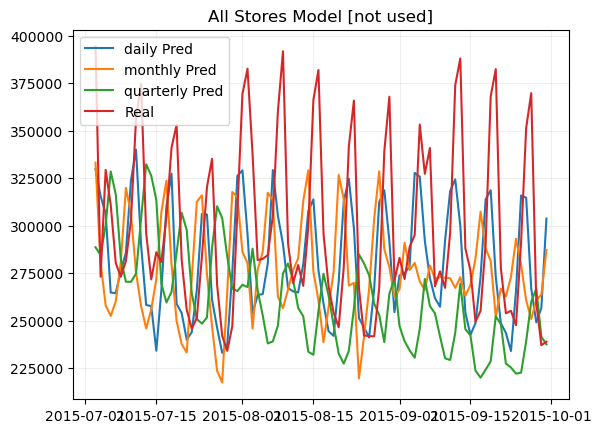

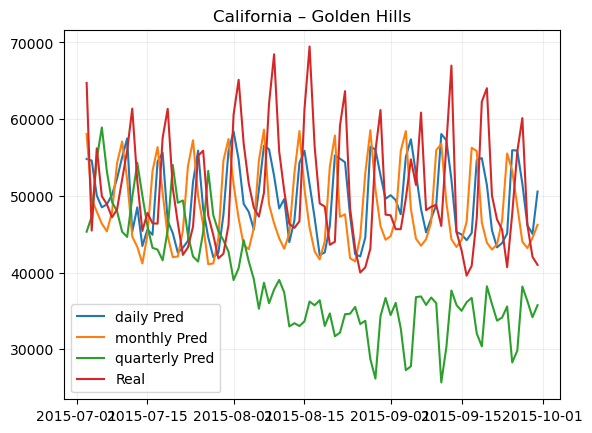

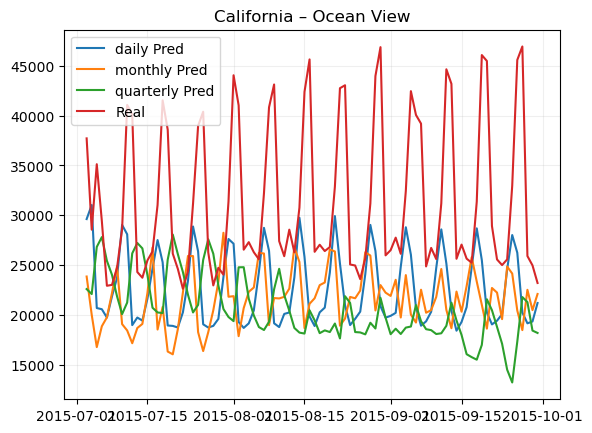

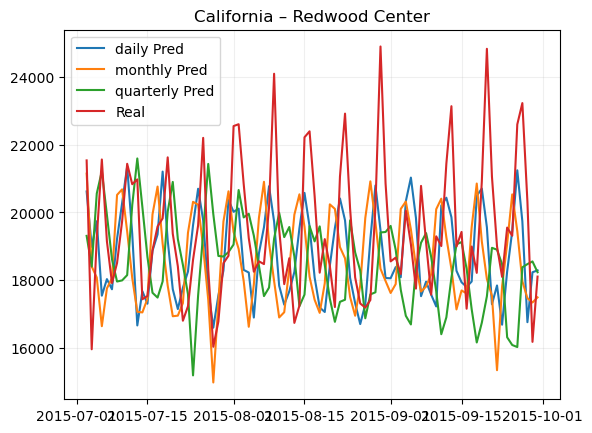

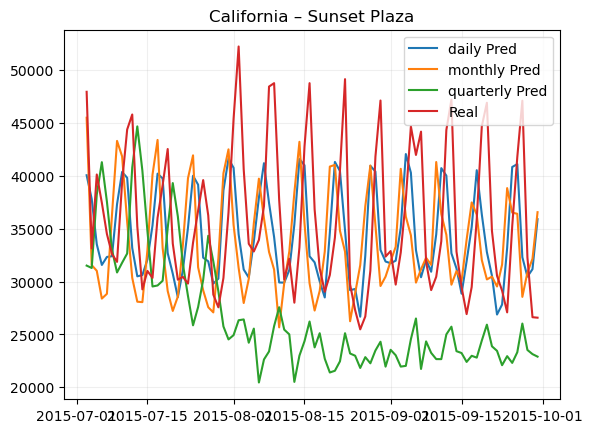

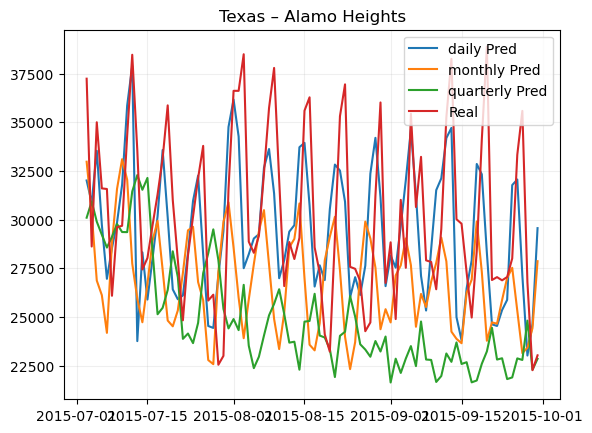

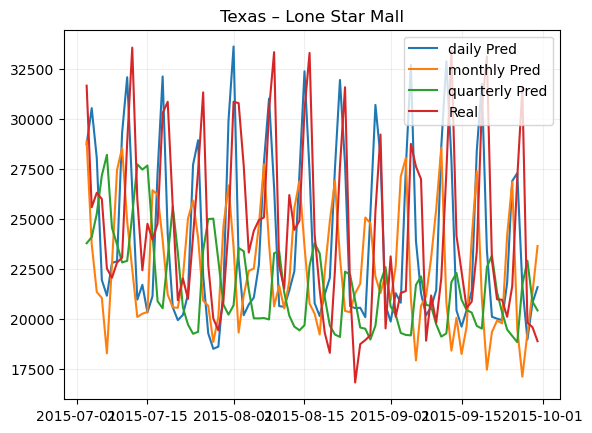

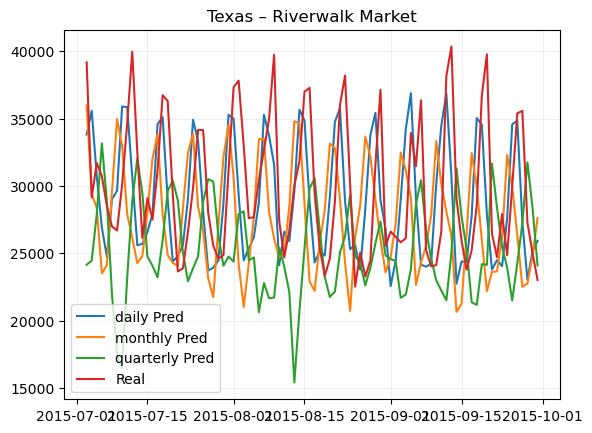

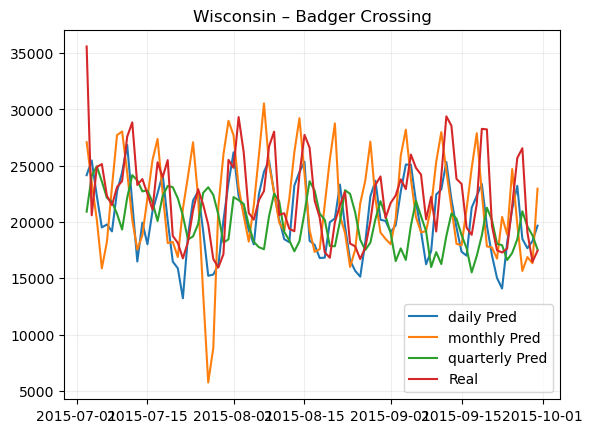

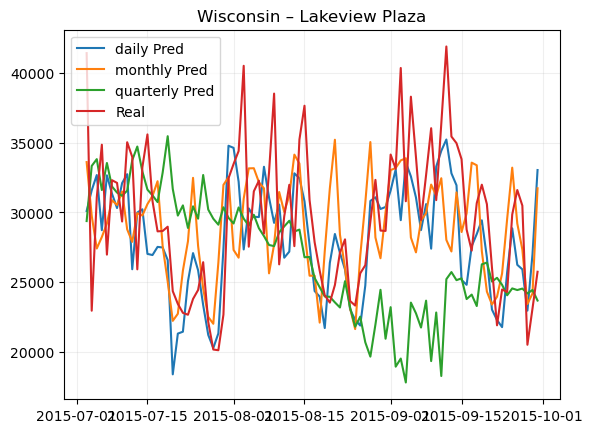

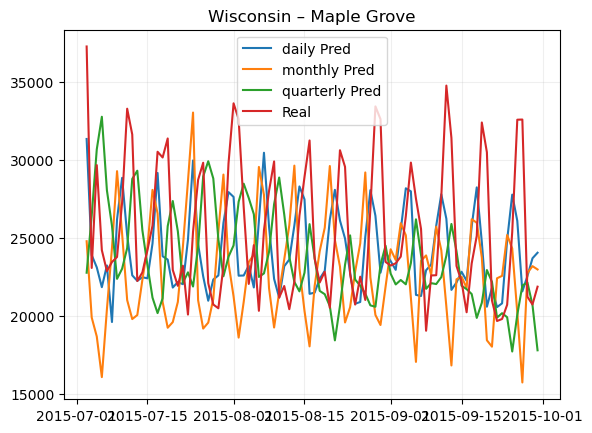

In [160]:
import matplotlib.pyplot as plt

# train, test_df, date = train_test_split_90(df)
# print(test_df[test_df['store_name'] == 'All Stores']['date'])

for store in store_results:
    
    train, test_df, date = train_test_split_90(df[df['store_name'] == store])
    if store == 'All Stores': 
        plt.title('All Stores Model [not used]')
    else:
        plt.title(store)
    pred = store_results[store]
    
    for period in pred:
        plt.plot(pred[period]['date'], pred[period]['pred_revenue'], label = f'{period} Pred')
        # break
    plt.grid(alpha = 0.2)
    
    # print(test_df[test_df['store_name'] == store]['date'])
    plt.plot(test_df[test_df['store_name'] == store]['date'], test_df[test_df['store_name'] == store]['revenue'], label = 'Real')
    plt.legend()
    plt.show()
    


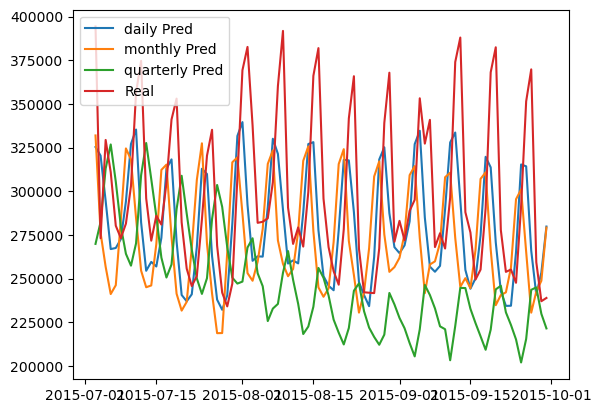

In [161]:
all_preds = {}
for model_name in ['daily', 'monthly', 'quarterly']:
    combined = (pd.concat([store_results[s][model_name] 
                           for s in store_results if s != 'All Stores'])
                  .groupby('date')['pred_revenue']
                  .sum()
                  .reset_index())
    all_preds[model_name] = combined

# all_preds
train, test_df, date = train_test_split_90(df[df['store_name'] == 'All Stores'])

for period in all_preds:
    plt.plot(all_preds[period]['date'], all_preds[period]['pred_revenue'], label = f'{period} Pred')
plt.plot(test_df[test_df['store_name']== 'All Stores']['date'], test_df[test_df['store_name']== 'All Stores']['revenue'], label = 'Real')
plt.legend()
plt.show()



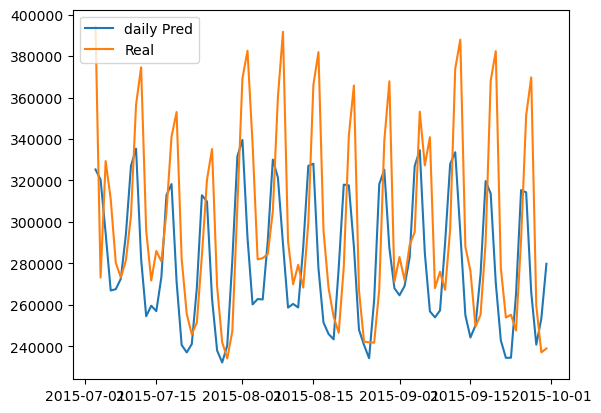

In [163]:
all_preds = {}
for model_name in ['daily', ]:
    combined = (pd.concat([store_results[s][model_name] 
                           for s in store_results if s != 'All Stores'])
                  .groupby('date')['pred_revenue']
                  .sum()
                  .reset_index())
    all_preds[model_name] = combined

# all_preds
train, test_df, date = train_test_split_90(df[df['store_name'] == 'All Stores'])

for period in all_preds:
    plt.plot(all_preds[period]['date'], all_preds[period]['pred_revenue'], label = f'{period} Pred')
plt.plot(test_df[test_df['store_name']== 'All Stores']['date'], test_df[test_df['store_name']== 'All Stores']['revenue'], label = 'Real')
plt.legend()
plt.show()



# Code for predicting competition final data 


In [164]:
future_models  = {}
future_results = {}

for store_name, group in df.groupby('store_name'):
    group = group.sort_values('date').reset_index(drop=True)

    # Use ALL data for training — no train/test split
    X_train = group[FEATURES]
    y_train = group['revenue']

    last_known   = dict(zip(group['date'], group['revenue']))
    event_cal    = dict(zip(group['date'], group['event_binary']))
    future_start = group['date'].max() + pd.Timedelta(days=1)

    print(f"\n{'='*65}")
    print(f"Store : {store_name}")
    print(f"Train : up to {group['date'].max().date()}  |  "
          f"Forecast : {future_start.date()} → "
          f"{(future_start + pd.Timedelta(days=89)).date()}")

    models  = {}
    results = {}

    for model_name, _, chunk_size in MODEL_CONFIGS:

        model = XGBRegressor(**XGB_PARAMS)
        model.fit(X_train, y_train, verbose=False)

        preds = recursive_predict_chunked(
            model          = model,
            total_days     = 90,
            chunk_size     = chunk_size,
            last_known     = last_known,
            start_date     = future_start,
            event_calendar = event_cal,
        )

        pred_df = pd.DataFrame(preds, columns=['date', 'pred_revenue'])
        print(f"  [{model_name:>10}]  "
              f"Forecast {future_start.date()} → {pred_df['date'].max().date()}")

        models[model_name]  = model
        results[model_name] = pred_df

    future_models[store_name]  = models
    future_results[store_name] = results

print(f"\n{'='*65}")
print("Done. Outputs:")
print("  future_models  → {store_name: {'daily', 'monthly', 'quarterly'}}")
print("  future_results → {store_name: {'daily', 'monthly', 'quarterly'}} (pred DataFrames)")


Store : All Stores
Train : up to 2015-09-30  |  Forecast : 2015-10-01 → 2015-12-29
  [     daily]  Forecast 2015-10-01 → 2015-12-29
  [   monthly]  Forecast 2015-10-01 → 2015-12-29
  [ quarterly]  Forecast 2015-10-01 → 2015-12-29

Store : California – Golden Hills
Train : up to 2015-09-30  |  Forecast : 2015-10-01 → 2015-12-29
  [     daily]  Forecast 2015-10-01 → 2015-12-29
  [   monthly]  Forecast 2015-10-01 → 2015-12-29
  [ quarterly]  Forecast 2015-10-01 → 2015-12-29

Store : California – Ocean View
Train : up to 2015-09-30  |  Forecast : 2015-10-01 → 2015-12-29
  [     daily]  Forecast 2015-10-01 → 2015-12-29
  [   monthly]  Forecast 2015-10-01 → 2015-12-29
  [ quarterly]  Forecast 2015-10-01 → 2015-12-29

Store : California – Redwood Center
Train : up to 2015-09-30  |  Forecast : 2015-10-01 → 2015-12-29
  [     daily]  Forecast 2015-10-01 → 2015-12-29
  [   monthly]  Forecast 2015-10-01 → 2015-12-29
  [ quarterly]  Forecast 2015-10-01 → 2015-12-29

Store : California – Sunset Pl

In [165]:
WEIGHTS = {
    'daily':     0.6,
    'monthly':   0.2,
    'quarterly': 0.2,
}

future_models  = {}
future_results = {}  # {store_name: df with columns [date, pred_daily, pred_monthly, pred_quarterly, pred_revenue]}

for store_name, group in df.groupby('store_name'):
    group = group.sort_values('date').reset_index(drop=True)

    X_train = group[FEATURES]
    y_train = group['revenue']

    last_known   = dict(zip(group['date'], group['revenue']))
    event_cal    = dict(zip(group['date'], group['event_binary']))
    future_start = group['date'].max() + pd.Timedelta(days=1)

    print(f"\n{'='*65}")
    print(f"Store : {store_name}")
    print(f"Train : up to {group['date'].max().date()}  |  "
          f"Forecast : {future_start.date()} → "
          f"{(future_start + pd.Timedelta(days=89)).date()}")

    models     = {}
    store_pred = None  # will hold merged predictions for this store

    for model_name, _, chunk_size in MODEL_CONFIGS:

        model = XGBRegressor(**XGB_PARAMS)
        model.fit(X_train, y_train, verbose=False)

        preds = recursive_predict_chunked(
            model          = model,
            total_days     = 92,
            chunk_size     = chunk_size,
            last_known     = last_known,
            start_date     = future_start,
            event_calendar = event_cal,
        )

        pred_df = (pd.DataFrame(preds, columns=['date', 'pred_revenue'])
                     .rename(columns={'pred_revenue': f'pred_{model_name}'}))

        store_pred = pred_df if store_pred is None else store_pred.merge(pred_df, on='date', how='inner')

        print(f"  [{model_name:>10}]  Forecast {future_start.date()} → {pred_df['date'].max().date()}")

        models[model_name] = model

    # Weighted blend for this store
    store_pred['pred_revenue'] = sum(
        WEIGHTS[m] * store_pred[f'pred_{m}'] for m in WEIGHTS
    )
    store_pred['store_name'] = store_name

    future_models[store_name]  = models
    future_results[store_name] = store_pred

# ── Aggregate across stores ──────────────────────────────────────────────────
all_stores = (pd.concat(future_results.values())
                .groupby('date')[['pred_daily', 'pred_monthly', 'pred_quarterly', 'pred_revenue']]
                .sum()
                .reset_index())

print(f"\n{'='*65}")
print("Done. Outputs:")
print("  future_models  → {store_name: {'daily', 'monthly', 'quarterly'}}")
print("  future_results → {store_name: df with per-model + blended pred_revenue}")
print("  all_stores     → aggregated forecast across all stores")


Store : All Stores
Train : up to 2015-09-30  |  Forecast : 2015-10-01 → 2015-12-29
  [     daily]  Forecast 2015-10-01 → 2015-12-31
  [   monthly]  Forecast 2015-10-01 → 2015-12-31
  [ quarterly]  Forecast 2015-10-01 → 2015-12-31

Store : California – Golden Hills
Train : up to 2015-09-30  |  Forecast : 2015-10-01 → 2015-12-29
  [     daily]  Forecast 2015-10-01 → 2015-12-31
  [   monthly]  Forecast 2015-10-01 → 2015-12-31
  [ quarterly]  Forecast 2015-10-01 → 2015-12-31

Store : California – Ocean View
Train : up to 2015-09-30  |  Forecast : 2015-10-01 → 2015-12-29
  [     daily]  Forecast 2015-10-01 → 2015-12-31
  [   monthly]  Forecast 2015-10-01 → 2015-12-31
  [ quarterly]  Forecast 2015-10-01 → 2015-12-31

Store : California – Redwood Center
Train : up to 2015-09-30  |  Forecast : 2015-10-01 → 2015-12-29
  [     daily]  Forecast 2015-10-01 → 2015-12-31
  [   monthly]  Forecast 2015-10-01 → 2015-12-31
  [ quarterly]  Forecast 2015-10-01 → 2015-12-31

Store : California – Sunset Pl

In [166]:
output = (pd.concat(future_results.values())[['store_name', 'date', 'pred_revenue']]
            .reset_index(drop=True))
output[output['store_name'] == 'All Stores']['prev_revenue'] = all_stores['pred_revenue']
output = output.merge(df[['store_name', 'store_id']].drop_duplicates(), on='store_name', how='left')

output = output.sort_values(['store_id', 'date'])

output['id'] = output['store_id'].astype(str) + '_' + output['date'].dt.strftime('%Y%m%d')
output[['id', 'pred_revenue']].rename(columns = {'pred_revenue': 'prediction'}).set_index('id').to_csv('results.csv')
# output[['id', 'pred_revenue']].to_csv('predictions.csv', index=False)

/var/folders/c7/tbr2ngwx7t7cgn3r342y7mym0000gn/T/ipykernel_41926/1785216527.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  output[output['store_name'] == 'All Stores']['prev_revenue'] = all_stores['pred_revenue']


In [167]:
output

,store_name,date,pred_revenue,store_id,id
0,All Stores,2015-10-01,274231.406250,0,0_20151001
1,All Stores,2015-10-02,299592.906250,0,0_20151002
2,All Stores,2015-10-03,346945.437500,0,0_20151003
3,All Stores,2015-10-04,369413.093750,0,0_20151004
4,All Stores,2015-10-05,292288.593750,0,0_20151005
...,...,...,...,...,...
823,Wisconsin – Badger Crossing,2015-12-27,20410.255859,10,10_20151227
824,Wisconsin – Badger Crossing,2015-12-28,14736.089844,10,10_20151228
825,Wisconsin – Badger Crossing,2015-12-29,13501.966797,10,10_20151229
826,Wisconsin – Badger Crossing,2015-12-30,15772.065430,10,10_20151230


ensemble

df

In [148]:
df= pd.read_csv('forecast_submission.csv')
df

,id,prediction
0,0_20151001,0
1,0_20151002,0
2,0_20151003,0
3,0_20151004,0
4,0_20151005,0
...,...,...
1007,10_20151227,0
1008,10_20151228,0
1009,10_20151229,0
1010,10_20151230,0


In [149]:
my_sub = output[['id', 'pred_revenue']].rename(columns = {'pred_revenue': 'prediction'}).set_index('id')
df.set_index('id')
final_df = my_sub.join(df, lsuffix='_sub', rsuffix='_df')
final_df

,prediction_sub,id,prediction_df
id,,,
0_20151001,274231.406250,NaN,NaN
0_20151002,299592.906250,NaN,NaN
0_20151003,346945.437500,NaN,NaN
0_20151004,369413.093750,NaN,NaN
0_20151005,292288.593750,NaN,NaN
...,...,...,...
10_20151227,20410.255859,NaN,NaN
10_20151228,14736.089844,NaN,NaN
10_20151229,13501.966797,NaN,NaN


In [150]:
df.join(my_sub, lsuffix='_sub', rsuffix='_df')

,id,prediction_sub,prediction_df
0,0_20151001,0,NaN
1,0_20151002,0,NaN
2,0_20151003,0,NaN
3,0_20151004,0,NaN
4,0_20151005,0,NaN
...,...,...,...
1007,10_20151227,0,NaN
1008,10_20151228,0,NaN
1009,10_20151229,0,NaN
1010,10_20151230,0,NaN


In [153]:
my_sub =my_sub.reset_index()
# missing_from_df = my_sub[~my_sub['id'].isin(df['id'])]['id']
# print(f"IDs in submission but missing from df: {len(missing_from_df)}")
# print(missing_from_df.head())
my_sub

,id,prediction
0,0_20151001,274231.406250
1,0_20151002,299592.906250
2,0_20151003,346945.437500
3,0_20151004,369413.093750
4,0_20151005,292288.593750
...,...,...
1007,10_20151227,20410.255859
1008,10_20151228,14736.089844
1009,10_20151229,13501.966797
1010,10_20151230,15772.065430


In [154]:
missing_from_sub = df[~df['id'].isin(my_sub['id'])]['id']
print(f"IDs in df but missing from submission: {len(missing_from_sub)}")
print(missing_from_sub.head())

IDs in df but missing from submission: 0
Series([], Name: id, dtype: object)


In [156]:
my_sub

,id,prediction
0,0_20151001,274231.406250
1,0_20151002,299592.906250
2,0_20151003,346945.437500
3,0_20151004,369413.093750
4,0_20151005,292288.593750
...,...,...
1007,10_20151227,20410.255859
1008,10_20151228,14736.089844
1009,10_20151229,13501.966797
1010,10_20151230,15772.065430


Alternative

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from datetime import timedelta

# ==========================================
# STEP 1: INITIAL CLEANING & SEPARATION
# ==========================================
print("Cleaning data and separating the cumulative store...")

# Ensure date is a datetime object
df['date'] = pd.to_datetime(df['date'])

# Convert your 'event' column to binary (0 for NaN, 1 for any event)
df['event_binary'] = df['event'].notna().astype(int)

# Separate individual stores from the cumulative "All Stores"
# Based on your snippet, 'All Stores' is store_id 0
individual_df = df[df['store_name'] != 'All Stores'].copy()
cumulative_actuals = df[df['store_name'] == 'All Stores'].copy()

# Strictly sort the individual data to prevent future leakage in lags
individual_df = individual_df.sort_values(['store_id', 'date']).reset_index(drop=True)

# ==========================================
# STEP 2: FEATURE ENGINEERING
# ==========================================
print("Engineering features...")

# 1. Temporal Features 
individual_df['day_of_week'] = individual_df['date'].dt.weekday
individual_df['day_of_month'] = individual_df['date'].dt.day
individual_df['month'] = individual_df['date'].dt.month
individual_df['is_weekend'] = individual_df['day_of_week'].isin([5, 6]).astype(int)

# 2. Event Lead-up
individual_df['event_tomorrow'] = individual_df.groupby('store_id')['event_binary'].shift(-1).fillna(0).astype(int)

# 3. Target Lags & Rolling Statistics (Using 92 days as the safe minimum lag)
MIN_LAG = 92

individual_df['lag_92'] = individual_df.groupby('store_id')['revenue'].shift(MIN_LAG)
individual_df['lag_99'] = individual_df.groupby('store_id')['revenue'].shift(MIN_LAG + 7)
individual_df['lag_120'] = individual_df.groupby('store_id')['revenue'].shift(MIN_LAG + 28)

individual_df['rolling_mean_7'] = individual_df.groupby('store_id')['lag_92'].transform(lambda x: x.rolling(7).mean())
individual_df['rolling_mean_28'] = individual_df.groupby('store_id')['lag_92'].transform(lambda x: x.rolling(28).mean())
individual_df['rolling_std_28'] = individual_df.groupby('store_id')['lag_92'].transform(lambda x: x.rolling(28).std())

# Drop rows that don't have enough history for the 92-day lag
model_df = individual_df.dropna(subset=['rolling_std_28']).reset_index(drop=True)

# ==========================================
# STEP 3: TIME-SERIES SPLITS (92-Day Horizon)
# ==========================================
HORIZON = 92
max_date = model_df['date'].max()
test_start_date = max_date - timedelta(days=HORIZON - 1)
val_start_date = test_start_date - timedelta(days=HORIZON)

train_df = model_df[model_df['date'] < val_start_date]
val_df = model_df[(model_df['date'] >= val_start_date) & (model_df['date'] < test_start_date)]
test_df = model_df[model_df['date'] >= test_start_date]

feature_cols = [
    'event_binary', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'event_tomorrow',
    'lag_92', 'lag_99', 'lag_120', 'rolling_mean_7', 'rolling_mean_28', 'rolling_std_28'
]
target_col = 'revenue'

print(f"Train end date: {train_df['date'].max().date()}")
print(f"Blind Test start date: {test_df['date'].min().date()}")

# ==========================================
# STEP 4: TRAINING & PREDICTING
# ==========================================
print("\nTraining LightGBM models...")

predictions_df = test_df[['date', 'store_id', 'store_name', 'revenue']].copy()
predictions_df['pred_revenue'] = 0.0

lgb_params = {
    'objective': 'tweedie',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'seed': 42,
    'verbose': -1
}

# Get list of unique individual stores
unique_stores = model_df['store_id'].unique()

for store in unique_stores:
    st_train = train_df[train_df['store_id'] == store]
    st_val = val_df[val_df['store_id'] == store]
    st_test = test_df[test_df['store_id'] == store]
    
    # Skip if a store somehow has no training data
    if len(st_train) == 0:
        continue
        
    dtrain = lgb.Dataset(st_train[feature_cols], label=st_train[target_col])
    dval = lgb.Dataset(st_val[feature_cols], label=st_val[target_col], reference=dtrain)
    
    model = lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dtrain, dval],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    preds = model.predict(st_test[feature_cols])
    predictions_df.loc[predictions_df['store_id'] == store, 'pred_revenue'] = preds

# ==========================================
# STEP 5: RECONSTRUCT 'ALL STORES'
# ==========================================
print("Aggregating predictions for 'All Stores'...")

# Sum the individual predictions by date
cumulative_preds = predictions_df.groupby('date')['pred_revenue'].sum().reset_index()

# Merge back with the actual 'All Stores' data we separated in Step 1
final_cumulative = cumulative_preds.merge(
    cumulative_actuals[['date', 'revenue']], 
    on='date', 
    how='inner'
)
final_cumulative['store_name'] = 'All Stores'


Cleaning data and separating the cumulative store...
Engineering features...
Train end date: 2015-03-30
Blind Test start date: 2015-07-01

Training LightGBM models...
Aggregating predictions for 'All Stores'...
Done! Check 'predictions_df' for individual stores and 'final_cumulative' for the total.


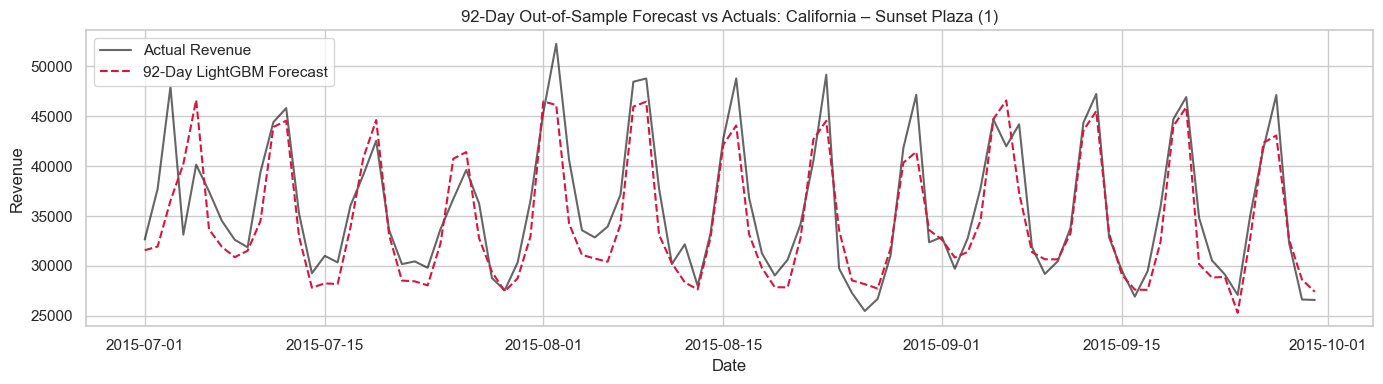

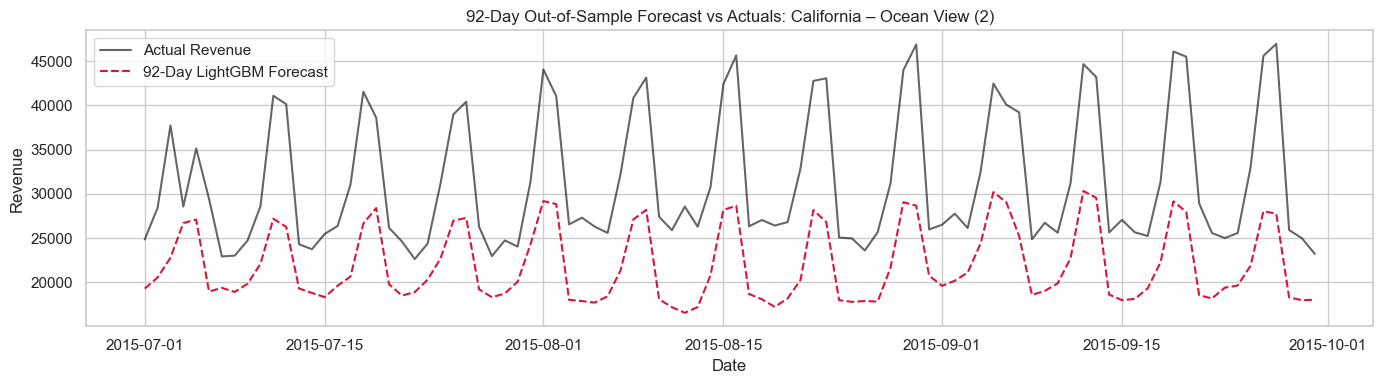

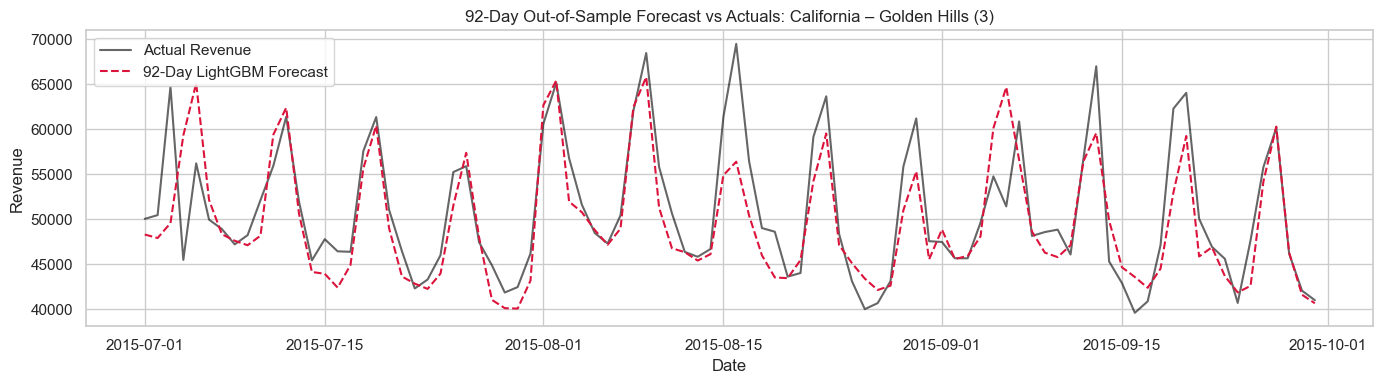

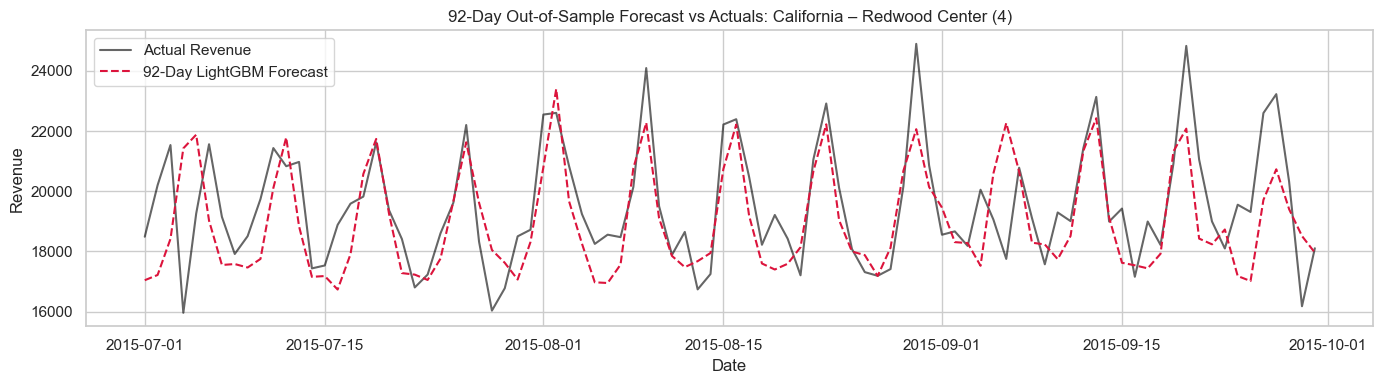

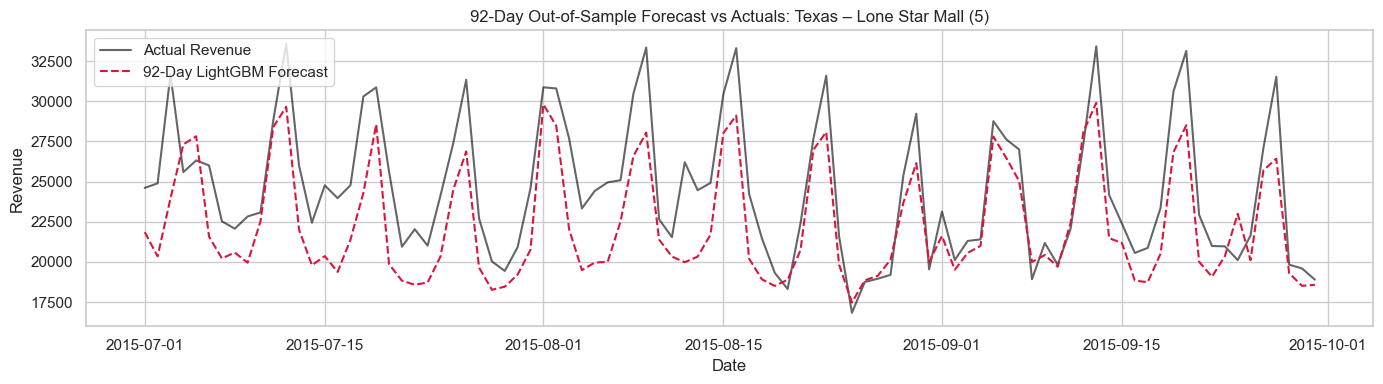

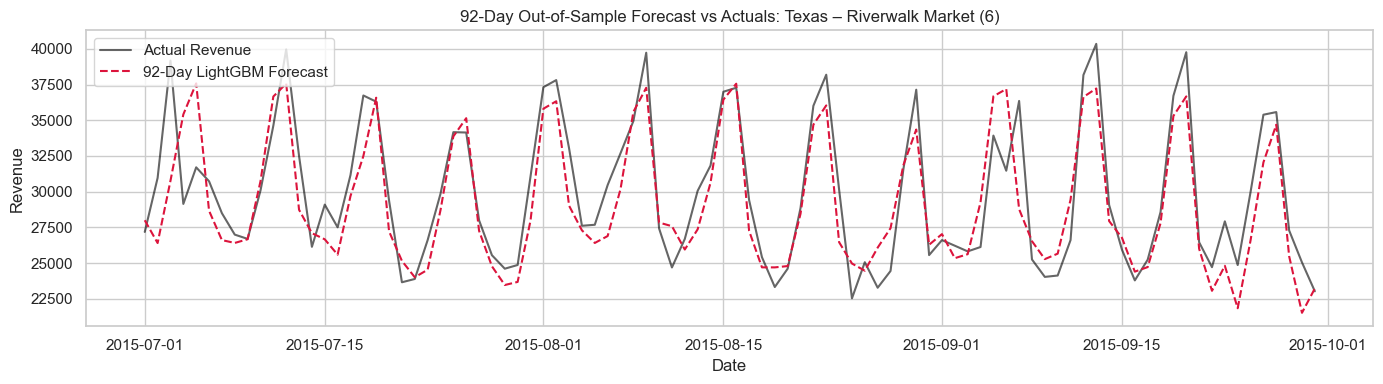

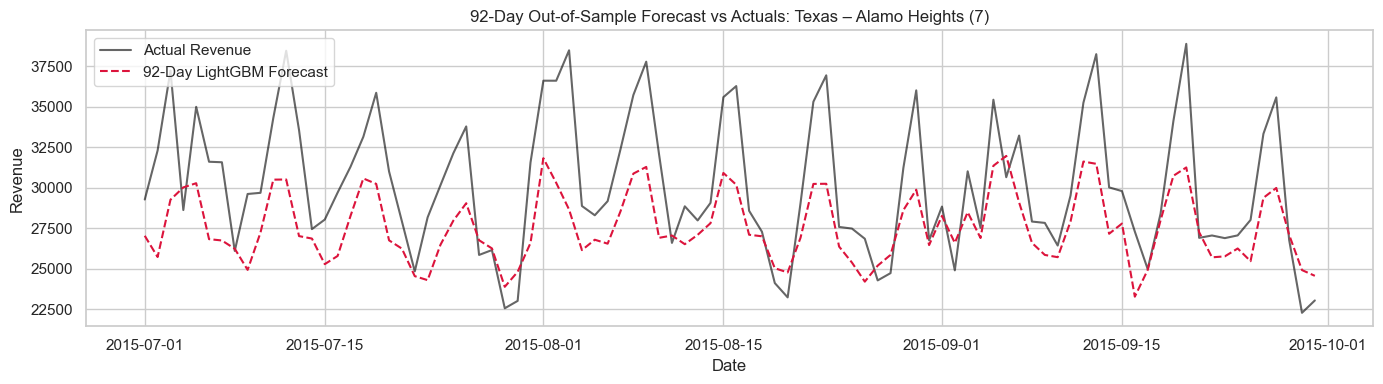

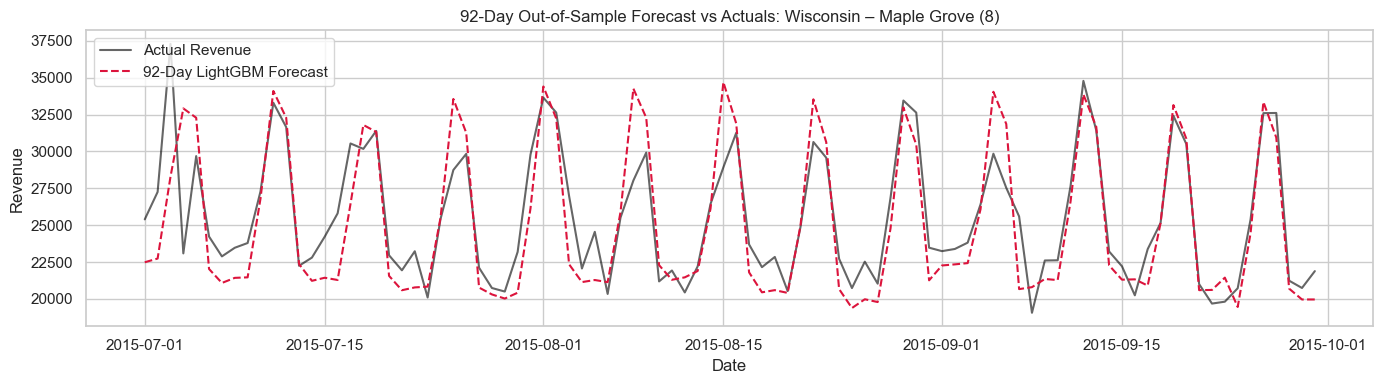

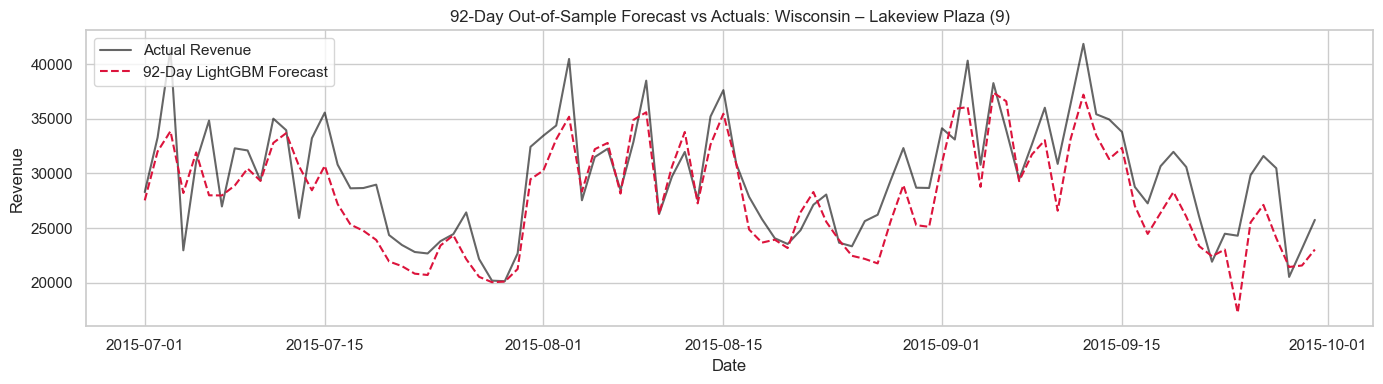

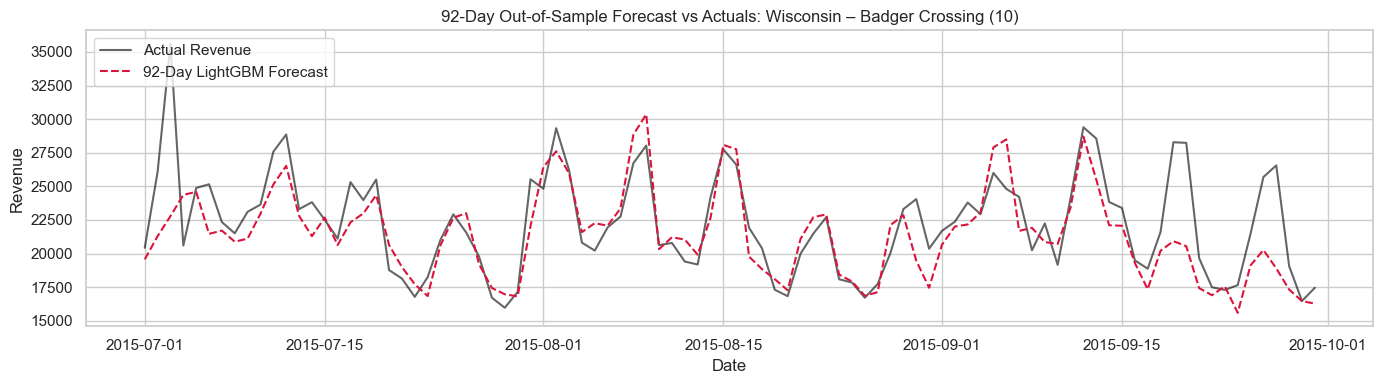

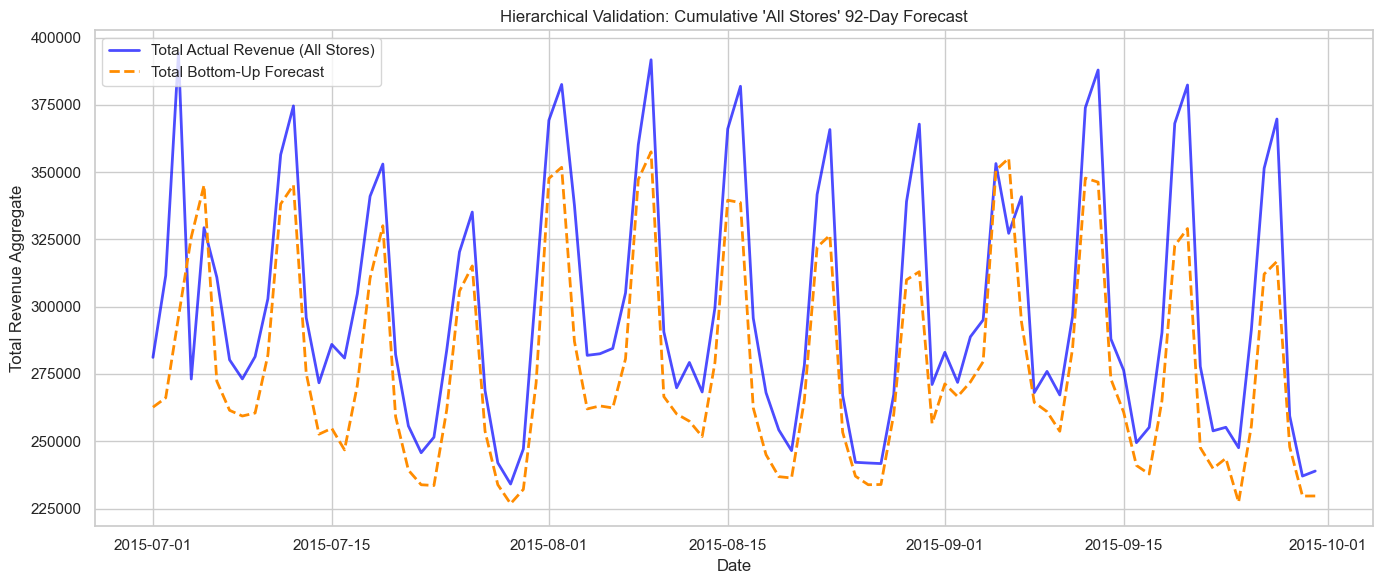

In [186]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clean visual metrics
sns.set_theme(style="whitegrid")

# 1. Plot Individual Stores
# Get the list of all unique individual stores predicted
unique_stores = predictions_df['store_id'].unique()

for store in unique_stores:
    store_data = predictions_df[predictions_df['store_id'] == store].sort_values('date')
    store_name = store_data['store_name'].iloc[0]
    
    plt.figure(figsize=(14, 4))
    plt.plot(store_data['date'], store_data['revenue'], label='Actual Revenue', color='black', alpha=0.6)
    plt.plot(store_data['date'], store_data['pred_revenue'], label='92-Day LightGBM Forecast', color='crimson', linestyle='--')
    
    plt.title(f"92-Day Out-of-Sample Forecast vs Actuals: {store_name} ({store})")
    plt.xlabel("Date")
    plt.ylabel("Revenue")
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

# 2. Plot Cumulative "All Stores" Aggregate
final_cumulative = final_cumulative.sort_values('date')

plt.figure(figsize=(14, 6))
# We use a thicker line to show the macro-level cumulative trend
plt.plot(final_cumulative['date'], final_cumulative['revenue'], label='Total Actual Revenue (All Stores)', color='blue', linewidth=2, alpha=0.7)
plt.plot(final_cumulative['date'], final_cumulative['pred_revenue'], label='Total Bottom-Up Forecast', color='darkorange', linestyle='--', linewidth=2)

plt.title("Hierarchical Validation: Cumulative 'All Stores' 92-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Total Revenue Aggregate")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()